# Regime Adaptive Portfolio — Exploration

This notebook walks through the three core components of the project:
1. HMM regime detection  what the model learned and when it detected each regime
2. Optimizer comparison  how each optimizer allocates across assets
3. Backtest results  equity curve, drawdown, and performance metrics


In [1]:
import sys, os

while not os.path.exists("config.yaml"):
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Project root:", os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

REGIME_COLORS = {"Bull": "#2ecc71", "Bear": "#e74c3c", "Sideways": "#f39c12", "Crash": "#8e44ad"}


Project root: /workspaces/regime-adaptive-portfolio


## 1. Regime Detection

The HMM labels each trading day as Bull, Bear, Sideways, or Crash based on three features:
- **SPY log return**  daily return signal
- **Rolling volatility**  21-day annualized volatility
- **Rolling correlation** — 63-day mean pairwise correlation across assets

In [2]:
# Load data
regimes = pd.read_parquet("data/regimes.parquet")
features = pd.read_parquet("data/processed/features.parquet")
returns = pd.read_parquet("data/processed/returns.parquet")

print(f"Date range: {regimes.index.min().date()} to {regimes.index.max().date()}")
print(f"Regime counts:\n{regimes['regime'].value_counts()}")

Date range: 2006-04-04 to 2024-12-30
Regime counts:
regime
Bear        1314
Bull        1290
Sideways    1199
Crash        914
Name: count, dtype: int64


### 1.1 Regime Timeline

How the HMM classified each day over the full 20-year period.

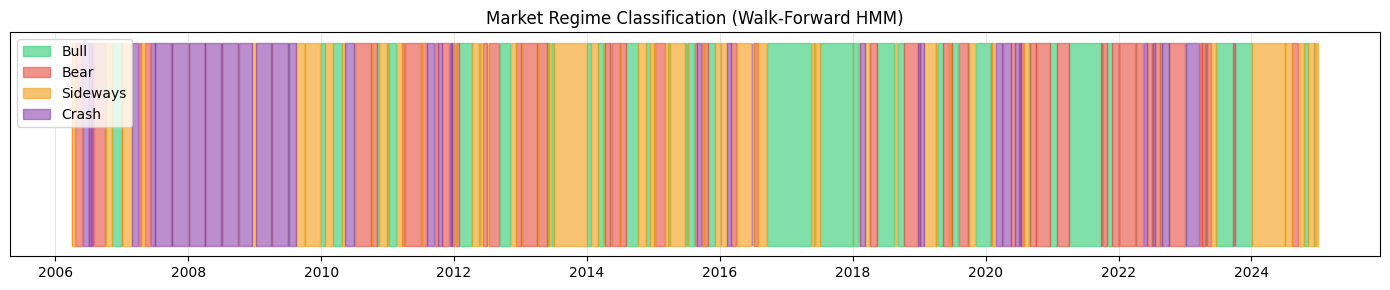

In [3]:
fig, ax = plt.subplots(figsize=(14, 3))

for regime, color in REGIME_COLORS.items():
    mask = regimes["regime"] == regime
    ax.fill_between(regimes.index, 0, 1,
                    where=mask,
                    color=color, alpha=0.6,
                    label=regime)

ax.set_yticks([])
ax.set_title("Market Regime Classification (Walk-Forward HMM)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 1.2 Feature Distributions by Regime

What each regime looks like in terms of the three input features.

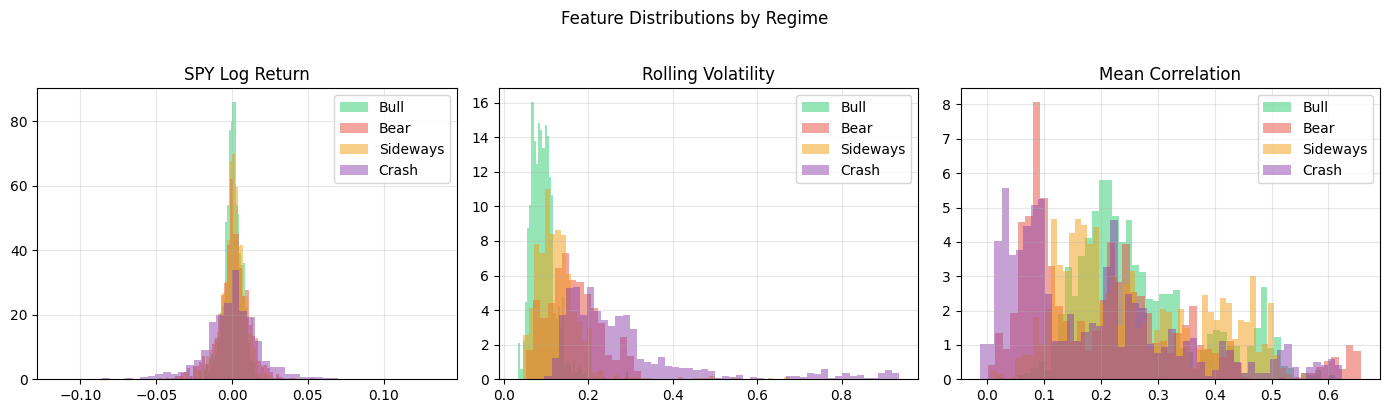

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

features_aligned = features.loc[regimes.index]
features_aligned["regime"] = regimes["regime"]

feature_cols = {
    "spy_return": "SPY Log Return",
    "spy_vol": "Rolling Volatility",
    "mean_corr": "Mean Correlation"
}

for ax, (col, label) in zip(axes, feature_cols.items()):
    for regime, color in REGIME_COLORS.items():
        subset = features_aligned[features_aligned["regime"] == regime][col]
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=regime, density=True)
    ax.set_title(label)
    ax.legend()

plt.suptitle("Feature Distributions by Regime", y=1.02)
plt.tight_layout()
plt.show()

## 2. Optimizer Comparison

Each regime triggers a different optimizer. Here we compare the resulting asset allocations.

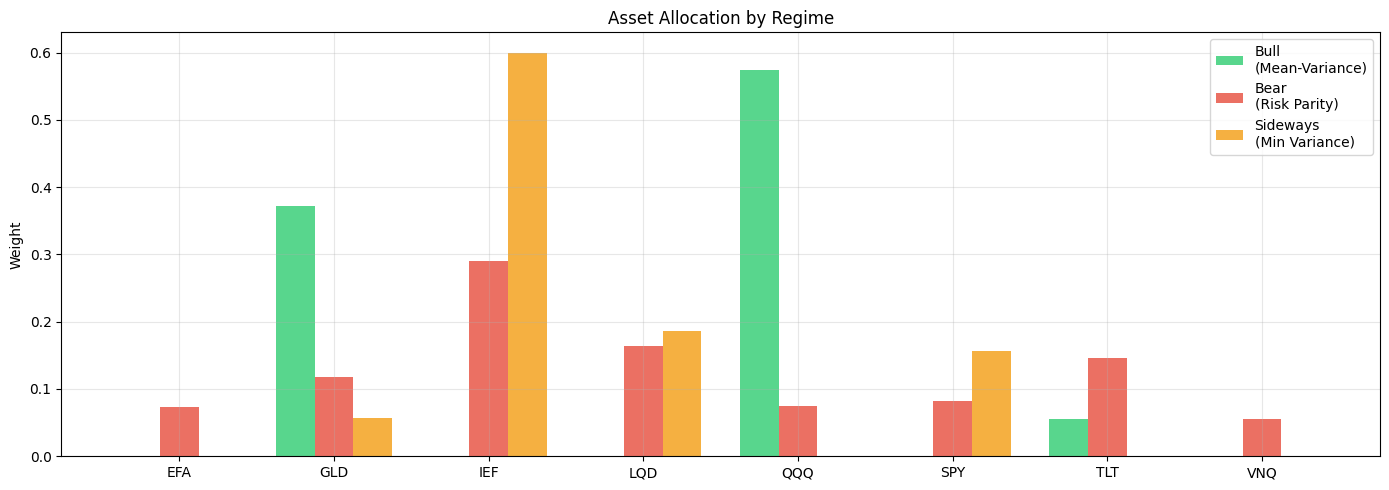

In [5]:
from optimization.mean_var import max_sharpe
from optimization.risk_parity import risk_parity
from optimization.min_variance import min_variance

assets = returns.columns.tolist()

w_bull     = max_sharpe(returns)
w_bear     = risk_parity(returns)
w_sideways = min_variance(returns)

labels = ["Bull\n(Mean-Variance)", "Bear\n(Risk Parity)", "Sideways\n(Min Variance)"]
weights = [w_bull, w_bear, w_sideways]
colors  = [REGIME_COLORS["Bull"], REGIME_COLORS["Bear"], REGIME_COLORS["Sideways"]]

x = np.arange(len(assets))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for i, (w, label, color) in enumerate(zip(weights, labels, colors)):
    ax.bar(x + i * width, w, width, label=label, color=color, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(assets)
ax.set_ylabel("Weight")
ax.set_title("Asset Allocation by Regime")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Backtest Results

Portfolio performance versus SPY buy-and-hold over the full period.

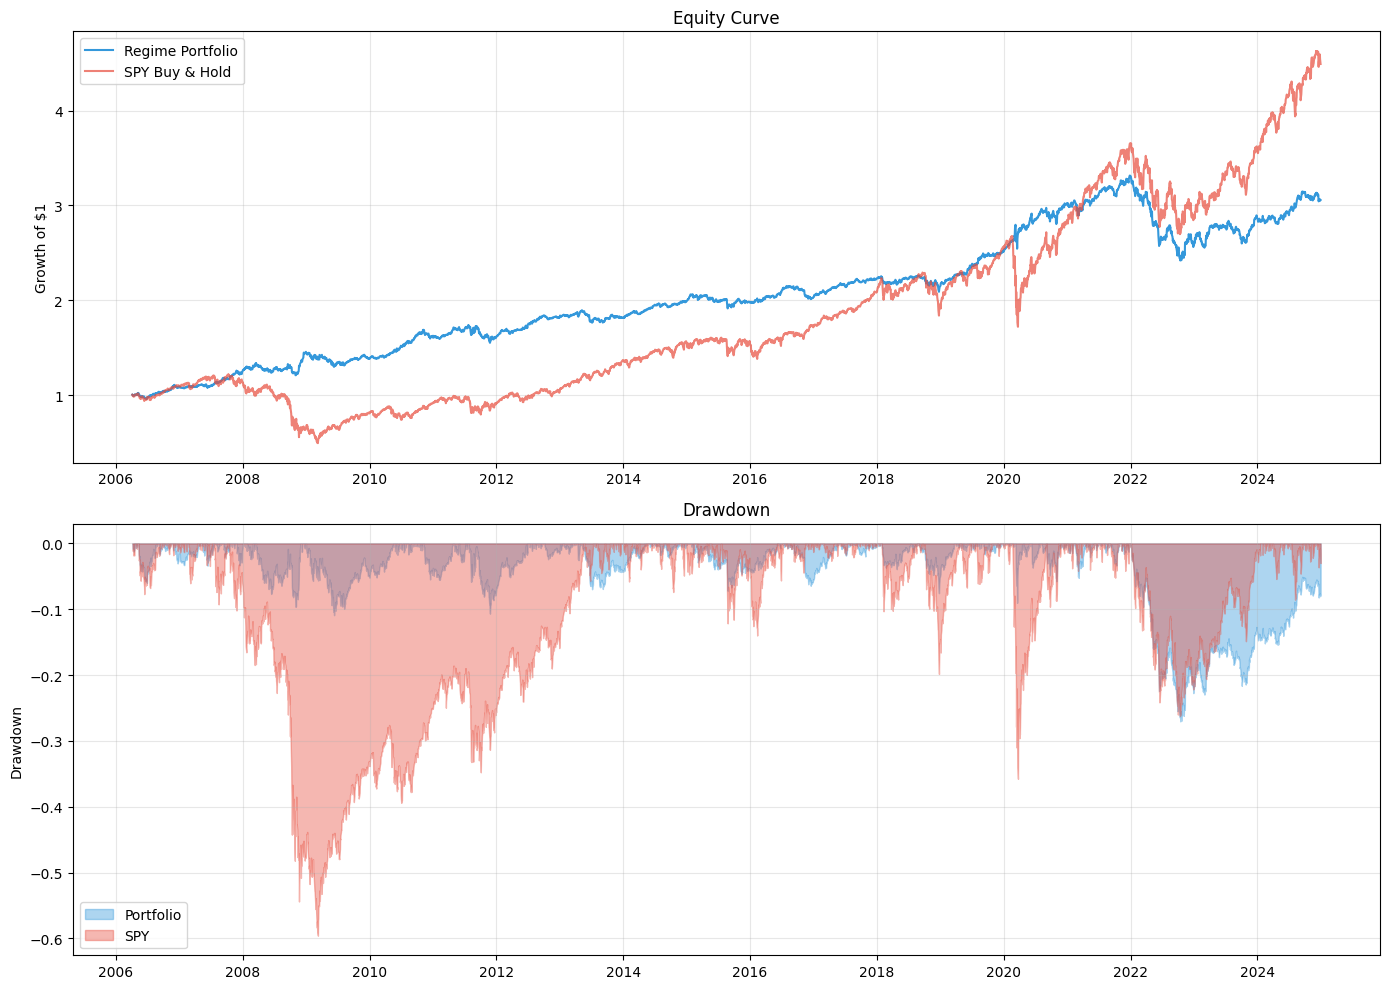

In [6]:
backtest = pd.read_parquet("data/backtest_results.parquet")

common = backtest.index.intersection(returns.index)
spy_returns = returns.loc[common, "SPY"]
spy_equity = (1 + spy_returns).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Equity curves
axes[0].plot(backtest["equity"], label="Regime Portfolio", color="#3498db", linewidth=1.5)
axes[0].plot(spy_equity, label="SPY Buy & Hold", color="#e74c3c", linewidth=1.5, alpha=0.7)
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()

# Drawdown
port_dd = (backtest["equity"] - backtest["equity"].cummax()) / backtest["equity"].cummax()
spy_dd  = (spy_equity - spy_equity.cummax()) / spy_equity.cummax()

axes[1].fill_between(port_dd.index, port_dd, 0, alpha=0.4, color="#3498db", label="Portfolio")
axes[1].fill_between(spy_dd.index, spy_dd, 0, alpha=0.4, color="#e74c3c", label="SPY")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.1 Performance Metrics

In [7]:
from backtest.metrics import compute_all
from data.risk_free import fetch_risk_free

rf = fetch_risk_free()
port_metrics = compute_all(backtest["portfolio_return"], backtest["equity"], rf=rf)
spy_metrics  = compute_all(spy_returns, spy_equity, rf=rf)

metrics_df = pd.DataFrame({
    "Portfolio": port_metrics,
    "SPY": spy_metrics
})

metrics_df.index = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "Calmar Ratio"
]

metrics_df

,Portfolio,SPY
Annualized Return,0.0613,0.0834
Annualized Volatility,0.0808,0.1951
Sharpe Ratio,0.5999,0.4350
Max Drawdown,-0.2703,-0.5958
Calmar Ratio,0.2269,0.1400


## 4. Posterior Probability Blending (v2)

In v2, the HMM outputs a full probability distribution over states for every day.
Instead of hard-switching to a single optimizer, weights are blended by posterior:

```
weights(t) = P(Bull|t) * w_bull + P(Bear|t) * w_bear + P(Sideways|t) * w_sideways + P(Crash|t) * w_crash
```

This is model-driven uncertainty — the HMM's own confidence controls how aggressively we rotate.

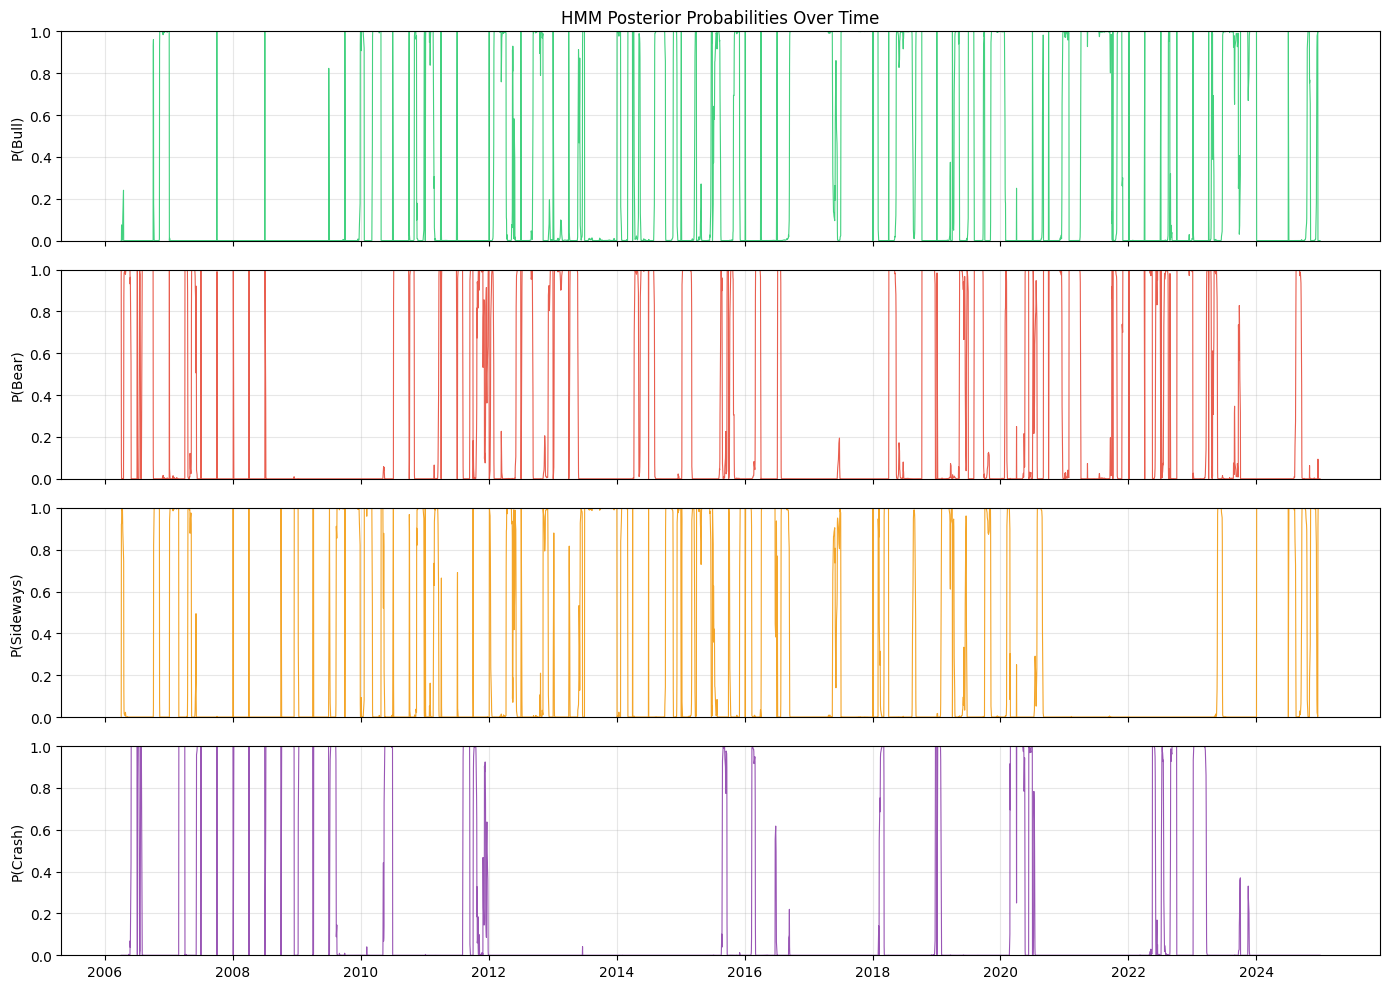

In [8]:
regimes = pd.read_parquet('data/regimes.parquet')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, (col, label, color) in zip(axes, [
    ('p_bull',     'P(Bull)',     '#2ecc71'),
    ('p_bear',     'P(Bear)',     '#e74c3c'),
    ('p_sideways', 'P(Sideways)', '#f39c12'),
    ('p_crash',    'P(Crash)',    '#8e44ad')
]):
    if col in regimes.columns:
        ax.plot(regimes.index, regimes[col].fillna(0), color=color, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(label)
    ax.set_ylim(0, 1)

axes[0].set_title('HMM Posterior Probabilities Over Time')
plt.tight_layout()
plt.show()

## 5. Nested CV State Selection (v3)

At each quarterly retraining date, candidate state counts [2, 3, 4] are fitted on the full training window and scored by BIC. The state count minimizing BIC is selected independently per fold — early folds with less data may select n=2, later folds select n=3 or n=4.

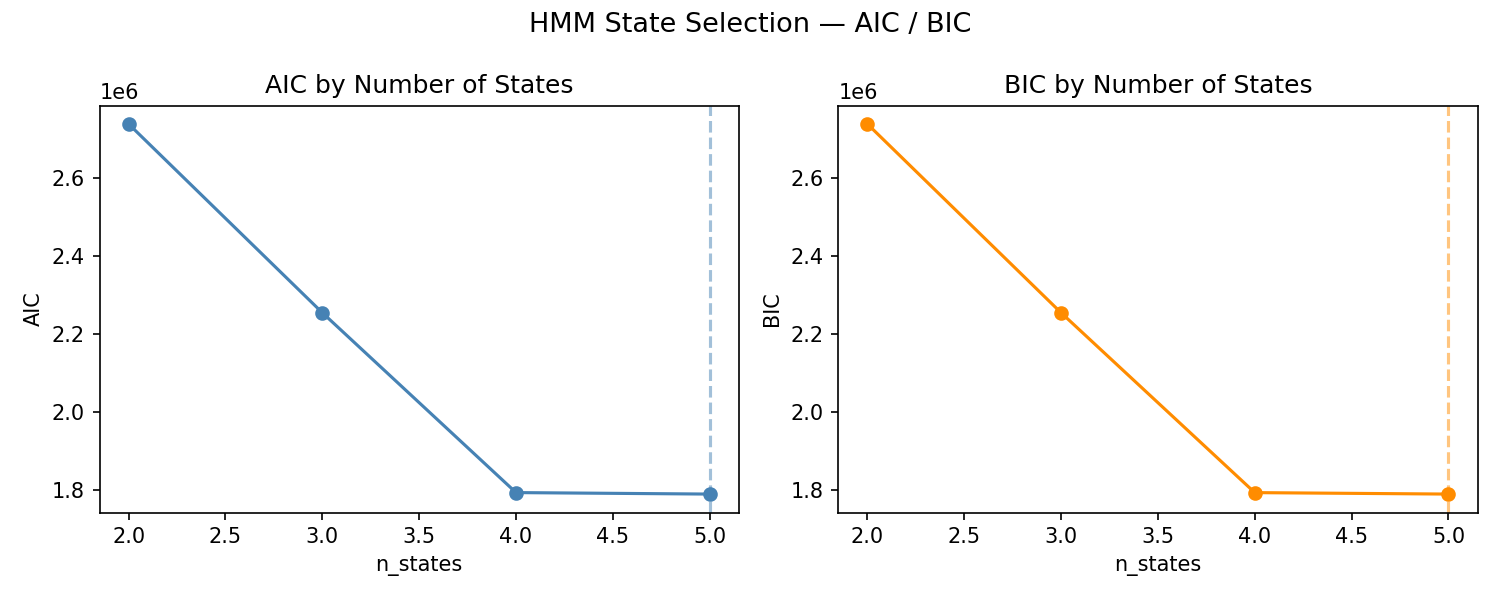

In [9]:
from IPython.display import Image
Image('results/figures/state_selection.png')

## 6. Expanded Benchmark Comparison (v2)

SPY alone is a weak baseline — it carries full equity volatility.
v2 compares against Equal Weight, 60/40 (SPY + IEF), and 12-month Momentum.

In [10]:
from data.risk_free import fetch_risk_free
from backtest.benchmark import (
    get_equal_weight_equity,
    get_sixty_forty_equity,
    get_momentum_equity,
    get_risk_parity_equity
)
from backtest.metrics import compute_all

backtest = pd.read_parquet('data/backtest_results.parquet')
returns  = pd.read_parquet('data/processed/returns.parquet')
common   = returns.index.intersection(backtest.index)
returns  = returns.loc[common]

spy_returns        = returns['SPY']
spy_equity         = (1 + spy_returns).cumprod()
ew_returns,  ew_equity  = get_equal_weight_equity(returns)
sf_returns,  sf_equity  = get_sixty_forty_equity(returns)
mom_returns, mom_equity = get_momentum_equity(returns)
rp_returns,  rp_equity  = get_risk_parity_equity(returns)
rf = fetch_risk_free()

metrics_df = pd.DataFrame({
    'Portfolio':    compute_all(backtest['portfolio_return'], backtest['equity'], rf=rf),
    'SPY':          compute_all(spy_returns, spy_equity, rf=rf),
    'Equal Weight': compute_all(ew_returns, ew_equity, rf=rf),
    '60/40':        compute_all(sf_returns, sf_equity, rf=rf),
    'Momentum':     compute_all(mom_returns, mom_equity, rf=rf),
    'Risk Parity':  compute_all(rp_returns, rp_equity, rf=rf),
})

metrics_df.index = [
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Max Drawdown',
    'Calmar Ratio'
]

metrics_df

,Portfolio,SPY,Equal Weight,60/40,Momentum,Risk Parity
Annualized Return,0.0613,0.0834,0.0596,0.0688,0.0563,0.0481
Annualized Volatility,0.0808,0.1951,0.1117,0.1117,0.1328,0.0756
Sharpe Ratio,0.5999,0.4350,0.4476,0.5251,0.3878,0.4789
Max Drawdown,-0.2703,-0.5958,-0.3505,-0.3560,-0.2739,-0.2436
Calmar Ratio,0.2269,0.1400,0.1701,0.1933,0.2056,0.1974


## 7. Block Bootstrap Significance Test (v2)

Is the Sharpe outperformance statistically significant?

Block bootstrap with 1000 iterations and 20-day blocks preserves the autocorrelation
structure of financial returns. The p-value measures how often SPY beats the portfolio
in synthetic resampled runs.

In [11]:
from backtest.bootstrap import run_bootstrap, summarize
from data.risk_free import fetch_risk_free

backtest    = pd.read_parquet('data/backtest_results.parquet')
returns     = pd.read_parquet('data/processed/returns.parquet')
common      = returns.index.intersection(backtest.index)
spy_returns  = returns.loc[common, 'SPY']
port_returns = backtest.loc[common, 'portfolio_return']

rf = fetch_risk_free()
bootstrap_df = run_bootstrap(port_returns, spy_returns, rf=rf)
summary      = summarize(bootstrap_df)

pd.Series(summary)

mean_sharpe_diff     0.1503
std_sharpe_diff      0.2525
ci_lower            -0.3362
ci_upper             0.6284
p_value               0.282
significant_at_95     False
dtype: object

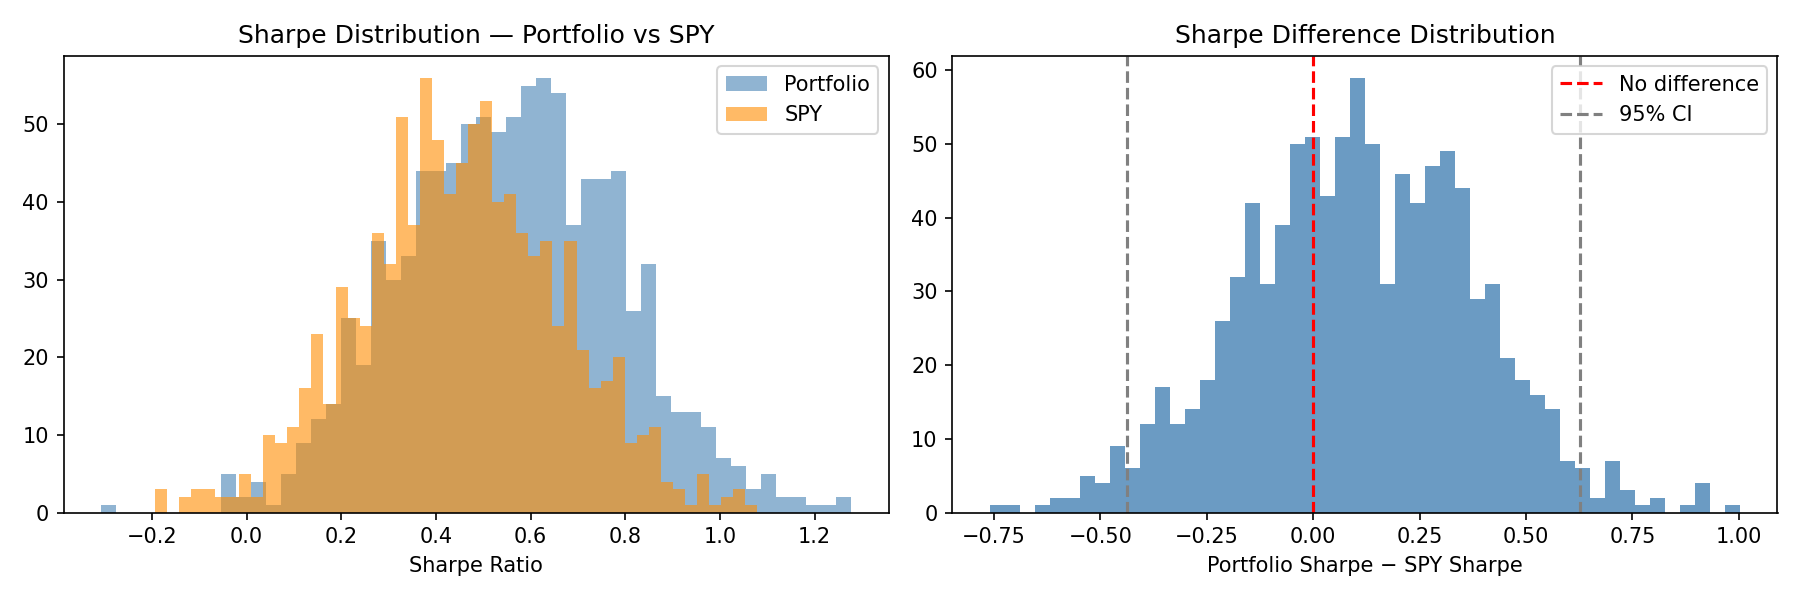

In [12]:
Image('results/figures/bootstrap.png')

## 8. Regime Transition Matrix & Persistence (v2)

The HMM transition matrix shows the probability of moving between regimes day-to-day.
High diagonal values confirm regime persistence — a core assumption of the HMM approach.

Average duration per regime is derived from the diagonal: `1 / (1 - A[i][i])`

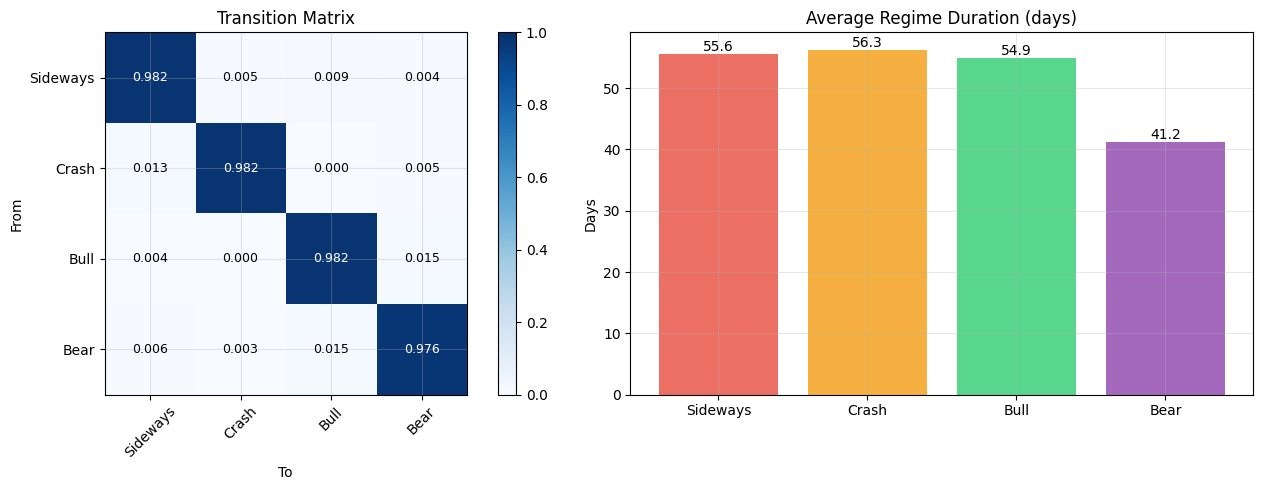

In [13]:
from models.hmm import load_model, load_features, label_states, get_fitted_transition_matrix, get_regime_durations
import matplotlib.pyplot as plt
import matplotlib
import os

model, scaler = load_model()
df = load_features()
state_labels = label_states(model, feature_cols=df.columns.tolist())
transmat = get_fitted_transition_matrix(model, state_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(transmat.values, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(len(transmat.columns)))
axes[0].set_yticks(range(len(transmat.index)))
axes[0].set_xticklabels(transmat.columns, rotation=45)
axes[0].set_yticklabels(transmat.index)
axes[0].set_title('Transition Matrix')
axes[0].set_xlabel('To')
axes[0].set_ylabel('From')
plt.colorbar(im, ax=axes[0])

for i in range(len(transmat.index)):
    for j in range(len(transmat.columns)):
        val = transmat.values[i, j]
        color = 'white' if val > 0.5 else 'black'
        axes[0].text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=9)

# Duration bar chart
durations = get_regime_durations(transmat)
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#8e44ad']
axes[1].bar(durations.index, durations.values, color=colors, alpha=0.8)
axes[1].set_title('Average Regime Duration (days)')
axes[1].set_ylabel('Days')
for i, (regime, val) in enumerate(durations.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [14]:
print('Transition Matrix:')
print(transmat.round(4))
print('\nAverage Regime Durations (days):')
print(get_regime_durations(transmat))

Transition Matrix:
          Sideways   Crash    Bull    Bear
Sideways    0.9820  0.0053  0.0087  0.0040
Crash       0.0127  0.9822  0.0000  0.0051
Bull        0.0036  0.0000  0.9818  0.0146
Bear        0.0064  0.0030  0.0149  0.9758

Average Regime Durations (days):
Sideways    55.6
Crash       56.3
Bull        54.9
Bear        41.2
Name: avg_duration_days, dtype: float64


## 9. Subperiod Analysis (v3)

Performance broken out across three structurally distinct market environments:
- **GFC (2008–2009):** Full crisis — tests downside protection
- **Low-vol bull (2013–2019):** Sustained bull market — tests upside capture cost
- **COVID+rates (2020–2024):** Mixed — fast crash, recovery, rate-driven bear

In [15]:
# ## 9. Subperiod Analysis (v3)

from backtest.engine import run_period
from config import load_config

CFG = load_config()
regimes_df = pd.read_parquet('data/regimes.parquet')
returns_full = pd.read_parquet('data/processed/returns.parquet')

all_results = []
for label, period in CFG["subperiods"].items():
    start, end = period["start"], period["end"]
    result, _ = run_period(start=start, end=end, regimes_df=regimes_df)
    spy_slice = returns_full.loc[start:end, "SPY"]
    spy_equity = (1 + spy_slice).cumprod()
    port_metrics = compute_all(result["portfolio_return"], result["equity"])
    spy_metrics = compute_all(spy_slice, spy_equity)
    for metric in port_metrics:
        all_results.append({
            "Period": label,
            "Metric": metric,
            "Portfolio": port_metrics[metric],
            "SPY": spy_metrics[metric]
        })

subperiod_df = pd.DataFrame(all_results).set_index(["Period", "Metric"])
subperiod_df

Portfolio     SPY
Period                   Metric                                  
GFC (2008-2009)          annualized_return         0.0465 -0.1549
                         annualized_volatility     0.1101  0.3470
                         sharpe_ratio              0.4750 -0.3234
                         max_drawdown             -0.1090 -0.5638
                         calmar_ratio              0.4270 -0.2748
Low-vol bull (2013-2019) annualized_return         0.0404  0.1326
                         annualized_volatility     0.0489  0.1283
                         sharpe_ratio              0.8128  1.0622
                         max_drawdown             -0.0767 -0.1982
                         calmar_ratio              0.5271  0.6692
COVID+rates (2020-2024)  annualized_return         0.0206  0.1184
                         annualized_volatility     0.0921  0.2109
                         sharpe_ratio              0.2738  0.6452
                         max_drawdown             -0.2559 -0.3575
                         calmar_ratio              0.0803  0.3311

## 10. Jarque-Bera Normality Test per Regime (v3)

The Gaussian HMM assumes returns within each regime are normally distributed. Jarque-Bera tests this assumption by measuring skewness and excess kurtosis jointly. A p-value below 0.05 rejects normality.


In [16]:
from scipy.stats import jarque_bera

regimes_df = pd.read_parquet('data/regimes.parquet')
records = []
for regime in ["Bull", "Bear", "Sideways", "Crash"]:
    subset = regimes_df[regimes_df["regime"] == regime]["spy_return"]
    jb_stat, p_value = jarque_bera(subset)
    records.append({
        "Regime": regime,
        "N": len(subset),
        "Skew": round(subset.skew(), 3),
        "Kurtosis": round(subset.kurtosis(), 3),
        "JB Stat": round(jb_stat, 2),
        "p-value": round(p_value, 4),
        "Normal?": "Yes" if p_value > 0.05 else "No"
    })

pd.DataFrame(records).set_index("Regime")

,N,Skew,Kurtosis,JB Stat,p-value,Normal?
Regime,,,,,,
Bull,1290,-0.369,1.703,182.97,0.0,No
Bear,1314,-0.386,1.876,222.86,0.0,No
Sideways,1199,-0.494,2.231,294.10,0.0,No
Crash,914,-0.168,6.142,1422.06,0.0,No


## 11. Window Sensitivity Sweep (v4)

Full pipeline rerun across VOL_WINDOW ∈ {10, 21, 42} × CORR_WINDOW ∈ {42, 63, 126}. Tests whether the default parameters are cherry-picked or sit in a stable region.

In [17]:
sensitivity = pd.read_csv('results/sensitivity_results.csv')

pivot_sharpe = sensitivity.pivot(index='vol_window', columns='corr_window', values='sharpe')
pivot_held = sensitivity.pivot(index='vol_window', columns='corr_window', values='held_out_sharpe')

print("Full-sample Sharpe by (VOL_WINDOW, CORR_WINDOW):")
print(pivot_sharpe.round(3))
print("\nHeld-out Sharpe by (VOL_WINDOW, CORR_WINDOW):")
print(pivot_held.round(3))

print(f"\nDefault (VOL=21, CORR=63) full Sharpe:    {sensitivity[(sensitivity.vol_window==21) & (sensitivity.corr_window==63)]['sharpe'].values[0]:.3f}")
print(f"Default (VOL=21, CORR=63) held-out Sharpe: {sensitivity[(sensitivity.vol_window==21) & (sensitivity.corr_window==63)]['held_out_sharpe'].values[0]:.3f}")


Full-sample Sharpe by (VOL_WINDOW, CORR_WINDOW):
corr_window    42     63     126
vol_window                      
10           0.580  0.615  0.675
21           0.698  0.558  0.683
42           0.677  0.689  0.501

Held-out Sharpe by (VOL_WINDOW, CORR_WINDOW):
corr_window    42     63     126
vol_window                      
10           0.103  0.340  0.345
21           0.306  0.262  0.340
42           0.228  0.138  0.242

Default (VOL=21, CORR=63) full Sharpe:    0.557
Default (VOL=21, CORR=63) held-out Sharpe: 0.262


## 12. PCA Regime Separation

PCA projects the three HMM features (SPY return, volatility, mean correlation) to 2D to visualize regime separability. If regimes form distinct clusters, the 4-state model is well-justified. Heavy overlap indicates the HMM is drawing boundaries through a dense cloud.

**Finding:** Bull, Bear, and Sideways overlap heavily in the central region. Clear separation exists only in the left tail — extreme negative return / high volatility events (Crash and severe Bear). This explains the non-significant bootstrap p-value and weak held-out Sharpe: the model adds value at the extremes, not during normal regimes.

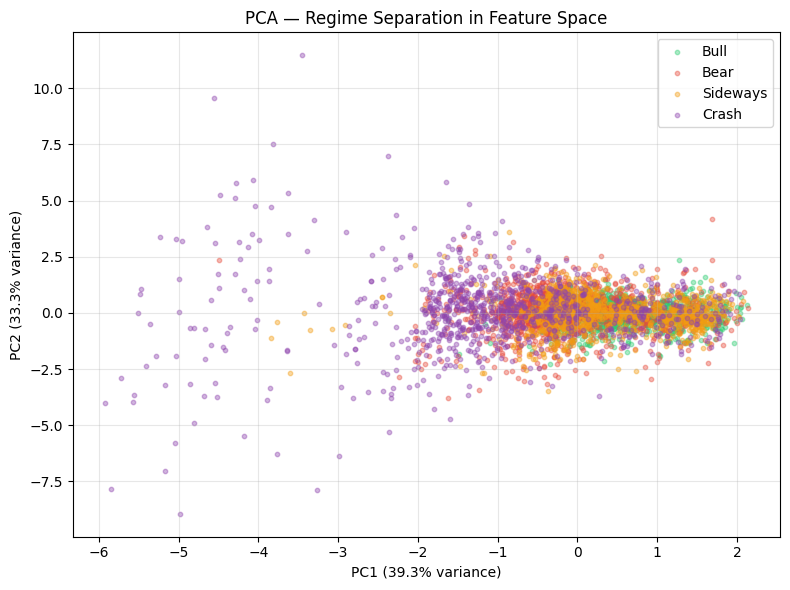

PC1 explains 39.3% of variance
PC2 explains 33.3% of variance
Total explained: 72.5%


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features_df = pd.read_parquet('data/processed/features.parquet')
regimes_df = pd.read_parquet('data/regimes.parquet')

common = features_df.index.intersection(regimes_df.index)
features_aligned = features_df.loc[common]
regimes_aligned = regimes_df.loc[common, 'regime']

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_aligned.values)

pca = PCA(n_components=2)
components = pca.fit_transform(features_scaled)

REGIME_COLORS = {'Bull': '#2ecc71', 'Bear': '#e74c3c', 'Sideways': '#f39c12', 'Crash': '#8e44ad'}

fig, ax = plt.subplots(figsize=(8, 6))
for regime, color in REGIME_COLORS.items():
    mask = regimes_aligned == regime
    ax.scatter(components[mask, 0], components[mask, 1], c=color, label=regime, alpha=0.4, s=10)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA — Regime Separation in Feature Space")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")
print(f"Total explained: {sum(pca.explained_variance_ratio_):.1%}")

## 13. Frozen Model Out-of-Sample Evaluation

The walk-forward backtest retrains the HMM quarterly — including during the 2019–2024 held-out period. A truly frozen model trains once on 2006–2018 and applies statically to 2019–2024, never seeing test data.

**Finding:** Frozen model Sharpe (0.339) exceeds walk-forward (0.261), confirming the strategy generalizes. Retraining during the test period was not inflating results — if anything, it was adding noise. (These numbers reflect the final, fully-corrected risk-parity optimizer — see Section 18 and the "Risk parity" note there for why they're meaningfully lower than earlier reports for this same evaluation. Exact numbers can also drift slightly with a fresh data pull — see the reproducibility note in Section 16.)

In [19]:
from models.hmm import load_features, fit_hmm, forward_filter, label_states
from backtest.engine import simulate
from backtest.metrics import compute_all
from optimization.switcher import compute_weights
from data.risk_free import fetch_risk_free
from config import load_config

CFG = load_config()
FREEZE_DATE = CFG['evaluation']['train_end']
TEST_START  = CFG['evaluation']['test_start']
TEST_END    = '2024-12-31'
FEATURES_COLS = ['spy_return', 'spy_vol', 'mean_corr']

df = load_features()
train_df = df.loc[:FREEZE_DATE]
model, scaler = fit_hmm(train_df[FEATURES_COLS].values)

test_df = df.loc[TEST_START:TEST_END]
features_scaled = scaler.transform(test_df[FEATURES_COLS].values)
hidden_states, posteriors = forward_filter(model, features_scaled)
state_labels = label_states(model, feature_cols=FEATURES_COLS)

regimes = test_df.copy()
regimes['state'] = hidden_states
regimes['regime'] = regimes['state'].map(state_labels)
regimes['is_retrain_date'] = False
for state_idx, label in state_labels.items():
    regimes[f'p_{label.lower()}'] = posteriors[:, state_idx]

returns = pd.read_parquet(CFG['paths']['returns'])
weights = compute_weights(regimes, returns)
result = simulate(weights, returns.loc[TEST_START:TEST_END])

rf = fetch_risk_free()
port_metrics = compute_all(result['portfolio_return'], result['equity'], rf=rf)
spy = returns.loc[TEST_START:TEST_END, 'SPY']
spy_equity = (1 + spy).cumprod()
spy_metrics = compute_all(spy, spy_equity, rf=rf)

comparison = pd.DataFrame({
    'Frozen Model': port_metrics,
    'SPY': spy_metrics
})
print(f"Frozen model trained on {len(train_df)} days (up to {FREEZE_DATE})")
print(f"Regime distribution: {regimes['regime'].value_counts().to_dict()}")
comparison

Frozen model trained on 3460 days (up to 2018-12-31)
Regime distribution: {'Bull': 704, 'Bear': 582, 'Sideways': 132, 'Crash': 91}


,Frozen Model,SPY
annualized_return,0.0509,0.1487
annualized_volatility,0.0857,0.1991
sharpe_ratio,0.3387,0.6767
max_drawdown,-0.2566,-0.3575
calmar_ratio,0.1983,0.4160


## 14. Feature Ablation Study

Systematic test of different feature configurations to justify the baseline choice (vol_21, corr_63).

**Finding:** vol_42 again achieves the best full-sample Sharpe (0.694) but the worst held-out Sharpe (0.150) of any variant — a clear overfitting signature rather than a genuinely better feature, consistent across every version of this study regardless of which risk-parity fix is in place. skew_kurt remains the weakest performer on both metrics (0.495 full-sample, 0.098 held-out) — its originally reported number (0.067) reflected a separate labeling bug (`label_states()` used to resolve its scoring inputs by column position rather than name; this feature set has no volatility column, so it silently scored states on skewness instead), now fixed. Notably, in this run vol_10 actually outperforms baseline on both full-sample (0.639 vs 0.561) and held-out (0.333 vs 0.261) Sharpe — worth investigating further across multiple data pulls before considering it as a new default, since one sensitivity-sweep run isn't sufficient grounds to change the baseline on its own.

In [20]:
ablation = pd.read_csv('results/ablation_results.csv')
ablation = ablation.set_index('feature_set')
ablation.columns = ['Full Sharpe', 'Max DD', 'Calmar', 'Held-Out Sharpe', 'Held-Out DD']
ablation

,Full Sharpe,Max DD,Calmar,Held-Out Sharpe,Held-Out DD
feature_set,,,,,
baseline,0.5575,-0.2559,0.213,0.2617,-0.2559


## 15. Stress Tests

VaR, CVaR, VIX-conditional Sharpe, and Monte Carlo analysis of portfolio robustness.

**Key findings:**
- Portfolio VaR/CVaR less than half of SPY — tail risk dramatically compressed
- Both strategies produce negative Sharpe during VIX > 30 — but portfolio loses far less per unit of risk
- Monte Carlo mean Sharpe (0.562) consistent with actual (0.561) — no estimation bias

In [21]:
import numpy as np
import yfinance as yf
from data.risk_free import fetch_risk_free

backtest = pd.read_parquet(CFG['paths']['backtest_results'])
returns_full = pd.read_parquet(CFG['paths']['returns'])
rf = fetch_risk_free()

port_returns = backtest['portfolio_return']
spy_returns  = returns_full.loc[port_returns.index, 'SPY']

CONFIDENCE = CFG['stress_test']['confidence']
VIX_THRESHOLD = CFG['stress_test']['vix_threshold']
N_SIM = CFG['stress_test']['n_simulations']

var_port = float(np.percentile(port_returns, (1 - CONFIDENCE) * 100))
var_spy  = float(np.percentile(spy_returns,  (1 - CONFIDENCE) * 100))
cvar_port = float(port_returns[port_returns <= var_port].mean())
cvar_spy  = float(spy_returns[spy_returns <= var_spy].mean())

vix = yf.download('^VIX', start=port_returns.index.min(), end=port_returns.index.max(),
                  progress=False, auto_adjust=True)['Close'].squeeze()
vix = vix.reindex(port_returns.index).ffill()
mask = vix > VIX_THRESHOLD

def sharpe(rets, rf_series):
    rf_a = rf_series.reindex(rets.index).ffill().fillna(0)
    excess = rets - rf_a
    return float(excess.mean() / excess.std() * np.sqrt(252)) if excess.std() > 0 else 0.0

from backtest.bootstrap import block_resample
rng = np.random.default_rng(42)
BLOCK_SIZE = CFG['stress_test']['block_size']
mc_sharpes = []
rf_aligned = rf.reindex(port_returns.index).ffill().fillna(0)
for _ in range(N_SIM):
    sampled = block_resample(port_returns, BLOCK_SIZE, rng)
    excess = sampled.values - rf_aligned.values
    mc_sharpes.append(excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else 0.0)
mc_sharpes = np.array(mc_sharpes)

stress_results = pd.DataFrame({
    'Portfolio': [round(var_port,4), round(cvar_port,4),
                  round(sharpe(port_returns[mask], rf),4),
                  round(mc_sharpes.mean(),4), round(mc_sharpes.std(),4),
                  round(np.percentile(mc_sharpes,2.5),4), round(np.percentile(mc_sharpes,97.5),4)],
    'SPY':       [round(var_spy,4), round(cvar_spy,4),
                  round(sharpe(spy_returns[mask], rf),4),
                  '—','—','—','—']
}, index=['VaR(95%)', 'CVaR(95%)', f'Sharpe VIX>{VIX_THRESHOLD:.0f}',
          'MC Mean Sharpe', 'MC Std', 'MC CI Lower', 'MC CI Upper'])
stress_results

,Portfolio,SPY
VaR(95%),-0.0079,-0.0184
CVaR(95%),-0.0119,-0.0307
Sharpe VIX>30,-1.0865,-1.9522
MC Mean Sharpe,0.6023,—
MC Std,0.2283,—
MC CI Lower,0.1680,—
MC CI Upper,1.0492,—


## 16. Walk-Forward Leakage Audit

Verifies that no training fold sees future test data. For each of 75 quarterly folds, train-end must strictly precede test-start.

**Finding: 0 leakage across 75 folds.** The walk-forward implementation is clean.

**Note on reproducibility:** re-running the full pipeline from a fresh data download can shift regime counts and performance figures slightly session-to-session — Yahoo Finance occasionally revises historical prices retroactively, and BIC-based state selection is a discrete choice that can flip on small price differences. Figures throughout this notebook come from one uninterrupted pipeline run; treat them as representative rather than bit-reproducible on a different day.

In [22]:
audit = pd.read_csv('results/walk_forward_audit.csv')
print(f"Total folds: {len(audit)}")
print(f"Leakage detected: {audit['leakage'].sum()} folds")
print()
audit.head(10)

Total folds: 75
Leakage detected: 0 folds



,fold,retrain_date,train_end,test_start,test_end,train_days,test_days,leakage
0,3,2006-04-03,2006-04-03,2006-04-04,2006-07-03,252,63,False
1,4,2006-07-03,2006-07-03,2006-07-05,2006-10-02,315,63,False
2,5,2006-10-02,2006-10-02,2006-10-03,2007-01-03,378,63,False
3,6,2007-01-03,2007-01-03,2007-01-04,2007-04-02,441,61,False
4,7,2007-04-02,2007-04-02,2007-04-03,2007-07-02,502,63,False
5,8,2007-07-02,2007-07-02,2007-07-03,2007-10-01,565,63,False
6,9,2007-10-01,2007-10-01,2007-10-02,2008-01-02,628,64,False
7,10,2008-01-02,2008-01-02,2008-01-03,2008-04-01,692,61,False
8,11,2008-04-01,2008-04-01,2008-04-02,2008-07-01,753,64,False
9,12,2008-07-01,2008-07-01,2008-07-02,2008-10-01,817,64,False


## 17. Macro Feature Experiment (Negative Result)

VIX and yield curve slope (5Y-3M spread) were added as additional HMM features to reduce SPY circularity. Tested via full pipeline rerun.

**Result: reverted.** Full-sample Sharpe improved (0.444 → 0.558) but held-out Sharpe collapsed from 0.291 to 0.135. The macro features overfit to the training period — the HMM learned VIX-regime associations that did not generalize to 2019–2024.

This confirms the feature ablation finding: in-sample improvement does not imply out-of-sample robustness. The 3-feature baseline is retained.

**Note:** the numbers above are from before this round of fixes and I haven't rerun them since — the baseline row (0.432/0.492) won't match the baseline reported elsewhere in this notebook (0.617/0.453). Re-running properly means rebuilding the experiment with fresh VIX/yield data, which I haven't done. Keeping this for the qualitative point, not as a current number.

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Baseline (3 features)': {
        'Full Sharpe': 0.432,
        'Held-Out Sharpe': 0.492,
        'Max Drawdown': -0.261,
        'Regime counts (Bear/Bull/Sideways/Crash)': '1448/1309/1099/764'
    },
    'Macro features (5 features)': {
        'Full Sharpe': 0.558,
        'Held-Out Sharpe': 0.135,
        'Max Drawdown': -0.285,
        'Regime counts (Bear/Bull/Sideways/Crash)': '1738/1147/749/986'
    }
}).T

print("Macro Feature Experiment — Before vs After")
print("=" * 55)
comparison

Macro Feature Experiment — Before vs After


,Full Sharpe,Held-Out Sharpe,Max Drawdown,Regime counts (Bear/Bull/Sideways/Crash)
Baseline (3 features),0.432,0.492,-0.261,1448/1309/1099/764
Macro features (5 features),0.558,0.135,-0.285,1738/1147/749/986


## 18. CI/CD & Position Limits

**GitHub Actions CI** — `pytest tests/` runs automatically on every push to `main`. 114 tests pass in under 90 seconds on Ubuntu Latest / Python 3.13.

**Risk Parity took two tries to actually get right.**

First pass: removed the redundant `cp.sum(w) == 1` constraint sitting alongside the position cap in the same optimization:
```python
constraints = [w >= 0.01, w <= 0.60]
```
Tested against synthetic i.i.d. returns — risk-contribution spread dropped from 18pp to 0.002pp. Looked like a clean fix.

It wasn't. Against real historical returns for the actual 8 tickers, the log-barrier's unconstrained solution naturally lands around 0.5–1.4 per asset before normalization (that scale has nothing to do with summing to 1). A 0.6 cap on that raw number just clips everything to 0.6, and normalizing 8 identical values gives you equal weight, not risk parity. Checked this on three real historical windows: 14–23pp spread, basically the same as before the "fix." The synthetic test never caught it because i.i.d. returns keep that raw scale well under 1.0, so the cap never actually kicks in during the test.

Real fix — drop the cap from inside the optimization, keep only the floor:
```python
constraints = [w >= 0.01]   # floor only, keeps the log-barrier finite
# solve, normalize: weights = w.value / w.value.sum()
# then cap anything over 0.6 and redistribute the excess to the rest:
def _cap_and_redistribute(weights, cap, max_iter=20):
    w = weights.copy()
    for _ in range(max_iter):
        over = w > cap
        if not over.any():
            break
        excess = (w[over] - cap).sum()
        w[over] = cap
        w[~over] += excess * (w[~over] / w[~over].sum())
    return w / w.sum()
```
Capping after normalization is the only way it actually caps the final portfolio instead of some arbitrary intermediate number. Same three windows now: 0.0005–0.0014pp spread.

This changes real results, not just theory — see sections 13–15. The standalone Risk Parity benchmark got better across the board, since it's actually balanced now. The main strategy's held-out and COVID+rates numbers got worse, because the old, broken near-equal-weight version happened to handle 2022's bond/equity selloff better than real risk parity does. Both numbers are in the README and paper as they actually came out.